# ESS 330 Final Project

Leona Myers (Colorado State University)  
Andie Hall (Colorado State University)

## Title

Title: Climate Change and Avian Response: Assessing the Effects of CO₂ and Temperature on Wood Thrush Populations

## Introduction:

Problem Overview: In recent decades, global climate change, driven by increased carbon dioxide emissions, has contributed to rising temperatures and disrupted ecological systems (@article{noaa2024climate). Many migratory bird species, such as the subject of this study, the Wood Thrush (Hylocichla mustelina), are particularly vulnerable to these changes due to their reliance on specific environmental cues for migration, breeding, and survival. The Wood Thrush is included on the Yellow Watch List for birds most at risk of extinction, and it is one of the most prominent examples of declining forest songbirds in North America (@article{cornell2024woodthrush). Populations have declined by 1.3% per year, resulting in a cumulative decline of approximately 50% between 1966 and 2019 (@article{cornell2024woodthrush). Declines in Wood Thrush populations have been observed across North America, yet the extent to which atmospheric CO2 levels and associated temperature changes contribute to these declines remains unclear. 

## Materials

This research will investigate the effects of atmospheric CO₂ concentrations and temperature changes on the population dynamics of the Wood Thrush (Hylocichla mustelina), a migratory songbird of conservation concern. The study integrates climate and ecological data from multiple large-scale sources: temperature records from the National Weather Service, (@article{noaa2024climate) bird abundance and distribution data from Cornell’s eBird Dataset (@article{cornell2024woodthrush), and atmospheric CO₂ data from the Global Carbon Budget (@article{friedlingstein2023global). Using these data sources, we can create a model to help determine the effect of these variables on the arrival and departure dates of these species along the mid-northeastern coast of the United States from 1966 to 2019.

## Methods Overview:

1.  Data acquisition

    1.  Climate Data: National Weather Service

    2.  CO₂ Data: Global Carbon Budget

    3.  Bird Observation Data: Cornell Lab’s eBird dataset

2.  Data Cleaning and Processing

    1.  Imported 7 different datasets from the states above that recorded annual temperatures for each month between 1966 and 2019 and combined into one large dataset, “All_Weather_Data.csv” 

        1.  Difficulties: The data was extremely time-consuming to clean and process into a large dataset due to the website’s pdf format for data exports. Using Excel’s data from the file helped to import the data and allowed for processing and cleaning of the data before being inserted into the rProject data directory. 

    2.  CO2 data was downloaded from the Global Carbon Budget and then uploaded to Rstudio. No additional cleaning was needed.

        1.  Difficulties may arise from this data set only including annual emission while other data sets include monthly data.

    3.  Filtered Wood Thrush eBird data to between the years of 1966 and 2019, along with filtering the location of the bird to these specific states: Pennsylvania, West Virginia, Virginia, Kentucky, Ohio, Indiana, and Tennessee. “Wood_Thrush_Raw.csv”

        1.  Difficulties: The dataset is about 131.5 MB and cannot be uploaded to the git repository, meaning data sharing had to be done via email rather than sharing the actual repo for us to pull and push.

1.  Statistical Analysis

    1.  Using the multiple datasets to account for temperature, CO2, and observations, we created multiple machine learning models: Linear Regression, Random Forest, and XGBoost. To identify the model of best fit, we created a workflow that would allow us to collect the metrics and determine the model we should choose based on the R-squared and RMSE values. 

    2.  Using two separate recipes to account for both the integration of temperature on observation dates, along with CO2 emissions, to ensure that they would not interfere with each other, and give us much more data to analyze. After prepping and baking the data, we created workflows to run the models. In total, we tested about 6 models, three for each recipe, and deciphered that Random Forest gives us the best predictions for both predictor variables. 

    3.  Once models were defined with both models and fitted to the resamples of the CV fold, we ran the models to determine their statistical significance and to see if the outcome of the model would give us data that would either prove or disprove our hypothesis. We then, with these models we create visualizations to represent and understand the data much better.  

2.  Visualization

    1.  Creating plots for the relationship between observation date and CO2, along with a separate relationship between observation date and temperature. In total, there will be four main graphs to understand their impact on both Spring Arrival dates and Fall Departure dates.

## Methods Discussion

1.  Have you chosen strong methods for your analysis?

    1.  We chose to go for a machine learning process, looking at three different models to see which would give us the best output of the relationship between the predictor variables (CO2 and temperature) and the outcome variable (observation date). Using the DayofYear function, we were able to use numeric values to understand correlations and determine our results. 

2.  Have you implemented them appropriately?

    1.  We had troubles along the way, especially with our best model, as it took a long time to render, possibly due to the large amount of data or the complex calculations needed to run the model. Our code did not encounter any physical errors and only had fairly long run times. We troubleshooted and asked for help when needed. 

3.  Have you clearly described them in a complete way in the form of a paper?

    1.  Hopefully, with the detail that we went into for the methods, after actually going through the process, it will be understandable and detail how we went through the analysis and will be cohesive enough to replicate our methods. 

4.  Could someone else replicate your analysis based on your method described?

    1.  Our methods could be replicable with different migratory species and predictor variables to examine a wide range of effects on the patterns of migratory wildlife. Our methods clearly outline the steps taken to complete this analysis.

## Preliminary: Exploring the Data

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at C:/Users/myersl3/OneDrive - Rensselaer Polytechnic Institute/Documents/leonamyers/github/Final-Project-330

CO2 data:

In [ ]:
Annua_CO2_Emissions <- read_csv(here("data", "annual-co2-emissions-per-country.csv"))

Rows: 54 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Entity
dbl (2): Year, Annual CO₂ emissions
lgl (1): Code

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

Weather Data:

In [ ]:
AllWeatherData <- read_csv(here("data", "AllWeatherData.csv"))

Rows: 378 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): STATE
dbl (14): Year, Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

eBird Data:

In [ ]:
Wood_Thrush <- read_csv(here("data", "Wood_Thrush.csv"))

New names:
Rows: 301512 Columns: 27
── Column specification
──────────────────────────────────────────────────────── Delimiter: "," chr
(6): COUNTRY, COUNTRY CODE, STATE, COUNTY, OBSERVATION COUNT, OBSERVATI... dbl
(2): LATITUDE, LONGITUDE lgl (19): ...6, ...10, ...11, ...12, ...13, ...14,
...15, ...16, ...17, ...1...
ℹ Use `spec()` to retrieve the full column specification for this data. ℹ
Specify the column types or set `show_col_types = FALSE` to quiet this message.
• `` -> `...6`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`

## Data Prep

In [ ]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.7     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.2.1
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.1.0
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Search for functions across packages at https://www.tidymodels.org/find/


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric

In [ ]:
Wood_Thrush <- Wood_Thrush |>
  select(COUNTRY, `COUNTRY CODE`, STATE, `OBSERVATION COUNT`, `OBSERVATION DATE`, LATITUDE, LONGITUDE) |>
  mutate(`OBSERVATION DATE` = as.Date(`OBSERVATION DATE`, format = "%m/%d/%Y"),
         Year = year(`OBSERVATION DATE`))

Annual_Weather <- AllWeatherData |>
  select(Year, Annual, STATE)

Annua_CO2_Emissions <- Annua_CO2_Emissions |>
  select(Year, `Annual CO₂ emissions`)

Main_Data <- Wood_Thrush |>
  inner_join(Annual_Weather, by = c("Year", "STATE")) |>
  inner_join(Annua_CO2_Emissions, by = "Year") |>
  mutate(DayOfYear = yday(`OBSERVATION DATE`)) |>
  drop_na(Annual, `Annual CO₂ emissions`, DayOfYear)

## Creating Data sets

In [ ]:
Spring_Arrival <- Main_Data |>
  group_by(year(`OBSERVATION DATE`)) |>
  slice_min(`OBSERVATION DATE`, with_ties = FALSE)

Fall_Departure <- Main_Data |>
  group_by(year(`OBSERVATION DATE`)) |>
  slice_max(`OBSERVATION DATE`, with_ties = FALSE)

## Splitting and CV folds

In [ ]:
set.seed(123)
WT_split <- initial_split(Main_Data, prop = 0.8)
WT_train <- training(WT_split)
WT_test  <- testing(WT_split)
WT_cv <- vfold_cv(WT_train, v = 5)

## Recipe

In [ ]:
CO2_rec <- recipe(formula = DayOfYear ~ `Annual CO₂ emissions`, data = WT_train) |>
  step_log(all_predictors()) |>
  step_naomit(all_predictors(), all_outcomes())

Temp_rec <- recipe(formula = DayOfYear ~ Annual, data = WT_train) |>
  step_log(all_predictors()) |>
  step_naomit(all_predictors(), all_outcomes())

## Define Models

In [ ]:
lm_model <- linear_reg() |> set_engine("lm") |> set_mode("regression")
rf_model <- rand_forest(trees = 100) |> set_engine("ranger") |> set_mode("regression")
xg_model <- boost_tree() |> set_engine("xgboost") |> set_mode("regression")

## CO2 Workflows

In [ ]:
wf_lm_CO2 <- workflow() |>
  add_model(lm_model) |>
  add_recipe(CO2_rec)

wf_rf_CO2 <- workflow() |>
  add_model(rf_model) |>
  add_recipe(CO2_rec)

wf_xg_CO2 <- workflow() |>
  add_model(xg_model) |>
  add_recipe(CO2_rec)

## Temperature Workflows

In [ ]:
wf_lm_Temp <- workflow() |>
  add_model(lm_model) |>
  add_recipe(Temp_rec)

wf_rf_Temp <- workflow() |>
  add_model(rf_model) |>
  add_recipe(Temp_rec)

wf_xg_Temp <- workflow() |>
  add_model(xg_model) |>
  add_recipe(Temp_rec)

## CO2: Linear Model

In [ ]:
res_lm_CO2 <- fit_resamples(
  wf_lm_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## CO2: Random Forest

In [ ]:
res_rf_CO2 <- fit_resamples(
  wf_rf_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## CO2: Boosted Tree

In [ ]:
res_xg_CO2 <- fit_resamples(
  wf_xg_CO2,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Linear Model

In [ ]:
res_lm_Temp <- fit_resamples(
  wf_lm_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Random Forest

In [ ]:
res_rf_Temp <- fit_resamples(
  wf_rf_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Temp: Boosted Tree

In [ ]:
res_xg_Temp <- fit_resamples(
  wf_xg_Temp,
  resamples = WT_cv,
  metrics = metric_set(rmse, rsq),
  control = control_resamples(save_pred = TRUE)
)

## Model Performances

In [ ]:
all_results <- bind_rows(
  collect_metrics(res_lm_CO2) |> mutate(Model = "LM - CO2"),
  collect_metrics(res_rf_CO2) |> mutate(Model = "RF - CO2"),
  collect_metrics(res_xg_CO2) |> mutate(Model = "XG - CO2"),
  collect_metrics(res_lm_Temp) |> mutate(Model = "LM - Temp"),
  collect_metrics(res_rf_Temp) |> mutate(Model = "RF - Temp"),
  collect_metrics(res_xg_Temp) |> mutate(Model = "XG - Temp")
)

all_results |> 
  filter(.metric == "rmse") |> 
  arrange(mean)

# A tibble: 6 × 7
  .metric .estimator  mean     n std_err .config              Model    
  <chr>   <chr>      <dbl> <int>   <dbl> <chr>                <chr>    
1 rmse    standard    37.5     5  0.0503 Preprocessor1_Model1 RF - Temp
2 rmse    standard    37.5     5  0.0518 Preprocessor1_Model1 XG - Temp
3 rmse    standard    37.6     5  0.0518 Preprocessor1_Model1 RF - CO2 
4 rmse    standard    37.6     5  0.0527 Preprocessor1_Model1 XG - CO2 
5 rmse    standard    37.7     5  0.0542 Preprocessor1_Model1 LM - CO2 
6 rmse    standard    37.7     5  0.0554 Preprocessor1_Model1 LM - Temp

## Fit to Full Model (Spring and Fall)

In [ ]:
rf_temp_spring_fit <- fit(wf_rf_Temp, data = Spring_Arrival)

rf_temp_fall_fit <- fit(wf_rf_Temp, data = Fall_Departure)

rf_CO2_spring_fit <- fit(wf_rf_CO2, data = Spring_Arrival)

rf_CO2_fall_fit <- fit(wf_rf_CO2, data = Fall_Departure)

## Plots and Predictions

In [ ]:
temp_spring_preds <- predict(rf_temp_spring_fit, Spring_Arrival) |>
  bind_cols(Spring_Arrival)

temp_fall_preds <- predict(rf_temp_fall_fit, Fall_Departure) |>
  bind_cols(Fall_Departure)

CO2_spring_preds <- predict(rf_CO2_spring_fit, Spring_Arrival) |>
  bind_cols(Spring_Arrival)

CO2_fall_preds <- predict(rf_CO2_fall_fit, Fall_Departure) |>
  bind_cols(Fall_Departure)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

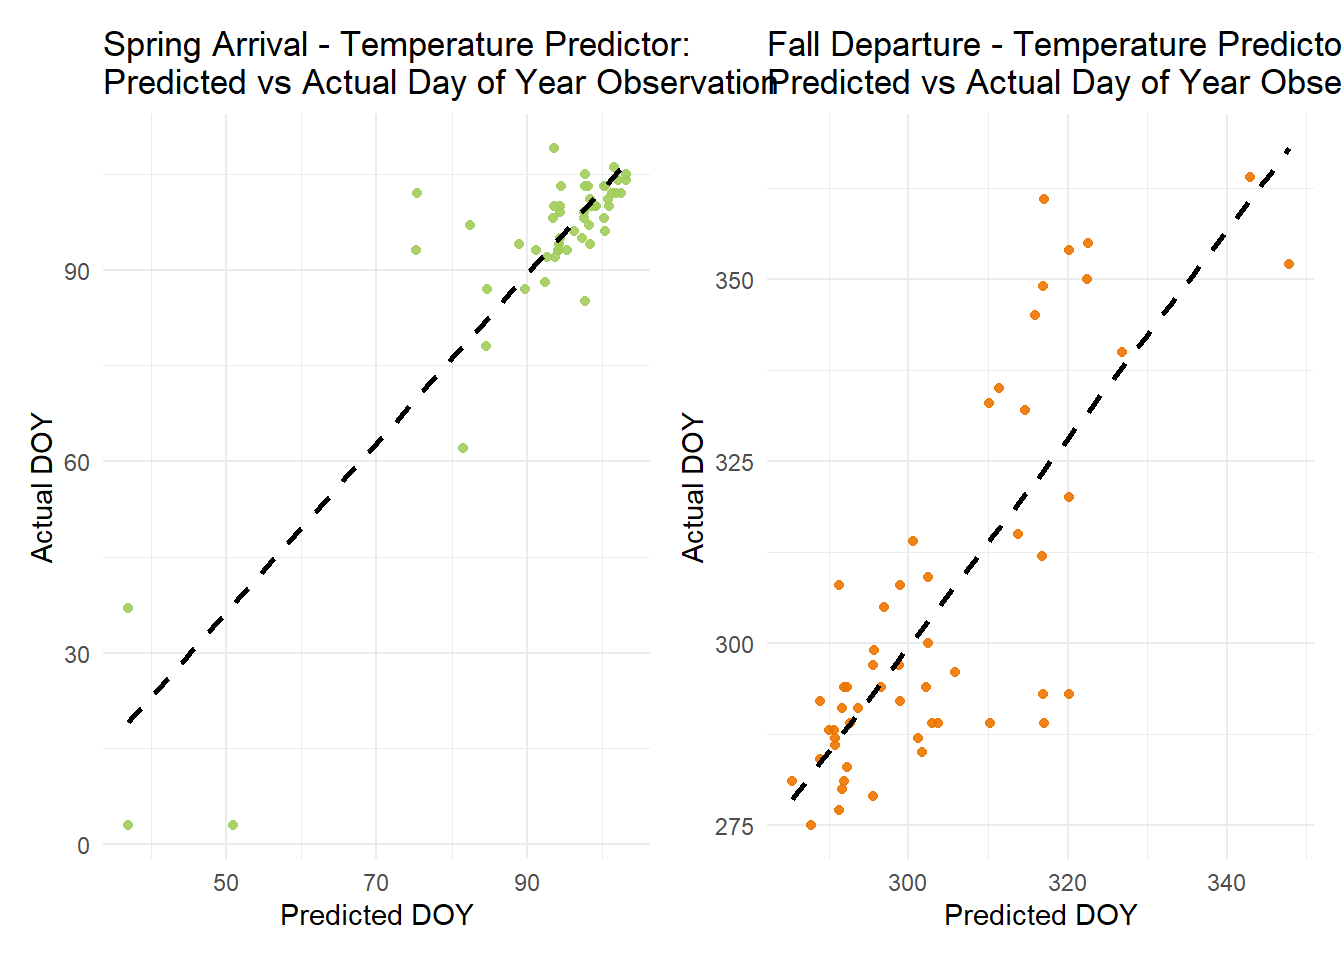

In [ ]:
library(patchwork) 

p1 <- ggplot(temp_spring_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "#A2CD5A") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Spring Arrival - Temperature Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")

p2 <- ggplot(temp_fall_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "darkorange2") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Fall Departure - Temperature Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")


p1 + p2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

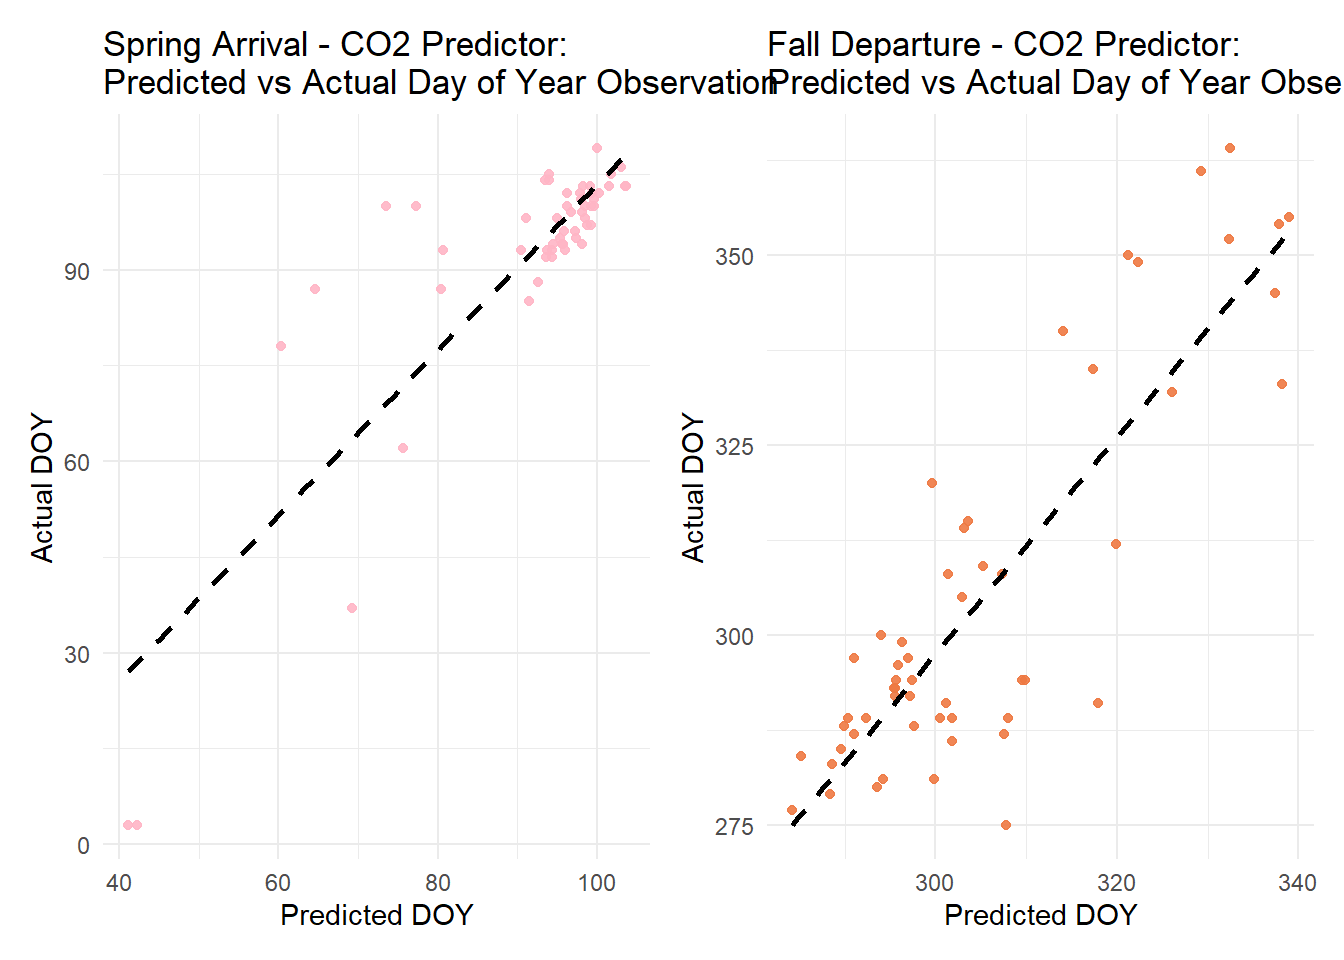

In [ ]:
p3 <- ggplot(CO2_spring_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "pink1") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Spring Arrival - CO2 Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")

p4 <- ggplot(CO2_fall_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "sienna2") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Fall Departure - CO2 Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")


p3 + p4

## **Results**

To assess the relationship between climate variables and Wood Thrush migration phenology, we implemented and evaluated six machine learning models: linear regression, random forest, and XGBoost—each applied separately to CO₂ and temperature predictor datasets. Performance was measured using 5-fold cross-validation due to the size of the dataset and runtime constraints.

In [ ]:
all_results <- bind_rows(
  collect_metrics(res_lm_CO2) |> mutate(Model = "LM - CO2"),
  collect_metrics(res_rf_CO2) |> mutate(Model = "RF - CO2"),
  collect_metrics(res_xg_CO2) |> mutate(Model = "XG - CO2"),
  collect_metrics(res_lm_Temp) |> mutate(Model = "LM - Temp"),
  collect_metrics(res_rf_Temp) |> mutate(Model = "RF - Temp"),
  collect_metrics(res_xg_Temp) |> mutate(Model = "XG - Temp")
)

all_results |> 
  filter(.metric == "rmse") |> 
  arrange(mean)

# A tibble: 6 × 7
  .metric .estimator  mean     n std_err .config              Model    
  <chr>   <chr>      <dbl> <int>   <dbl> <chr>                <chr>    
1 rmse    standard    37.5     5  0.0503 Preprocessor1_Model1 RF - Temp
2 rmse    standard    37.5     5  0.0518 Preprocessor1_Model1 XG - Temp
3 rmse    standard    37.6     5  0.0518 Preprocessor1_Model1 RF - CO2 
4 rmse    standard    37.6     5  0.0527 Preprocessor1_Model1 XG - CO2 
5 rmse    standard    37.7     5  0.0542 Preprocessor1_Model1 LM - CO2 
6 rmse    standard    37.7     5  0.0554 Preprocessor1_Model1 LM - Temp

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

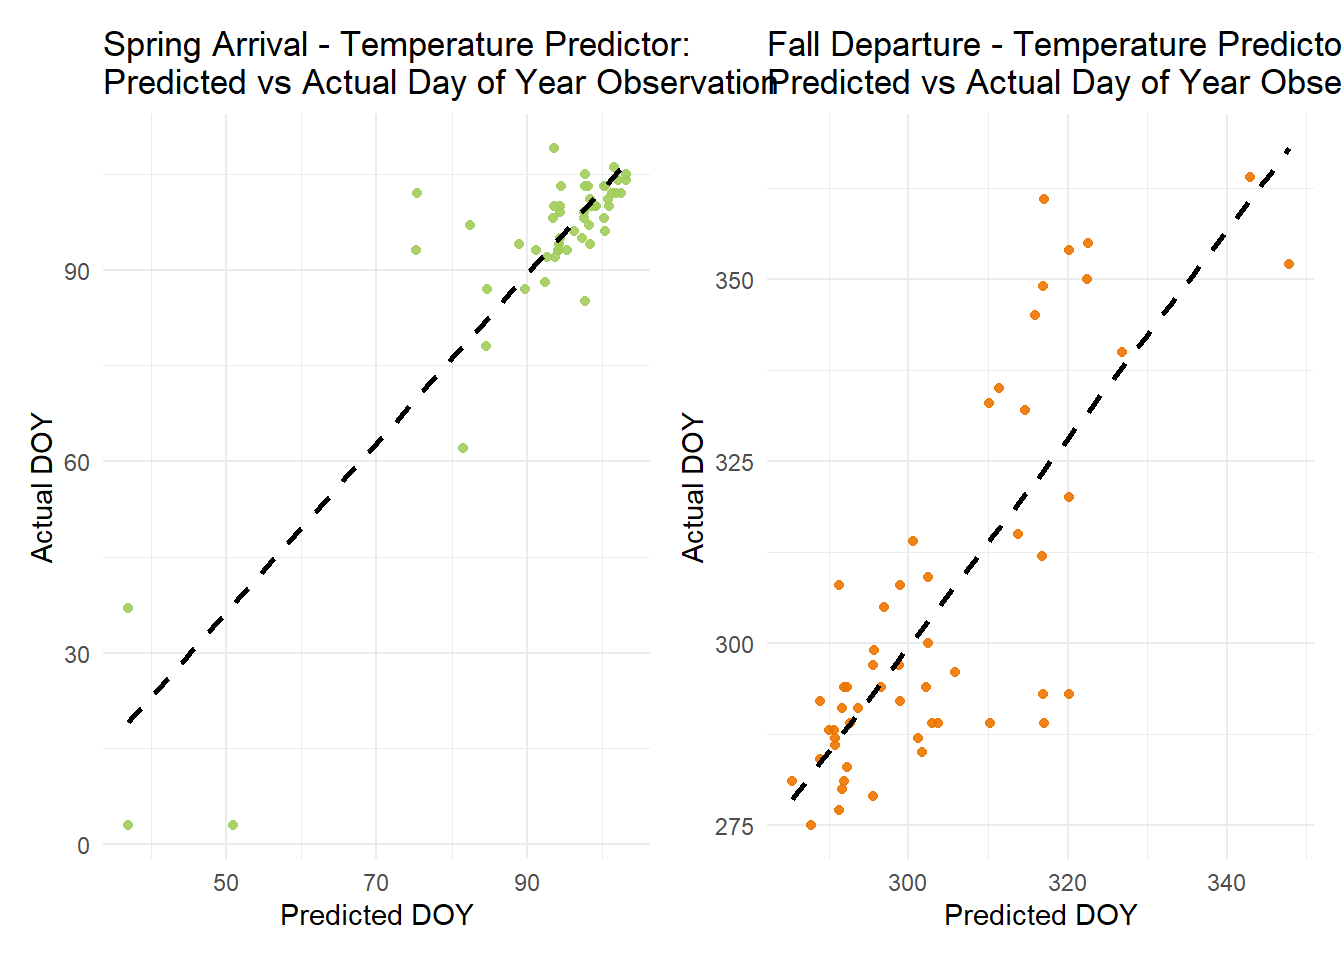

In [ ]:
library(patchwork) 

p1 <- ggplot(temp_spring_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "#A2CD5A") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Spring Arrival - Temperature Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")

p2 <- ggplot(temp_fall_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "darkorange2") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Fall Departure - Temperature Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")


p1 + p2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

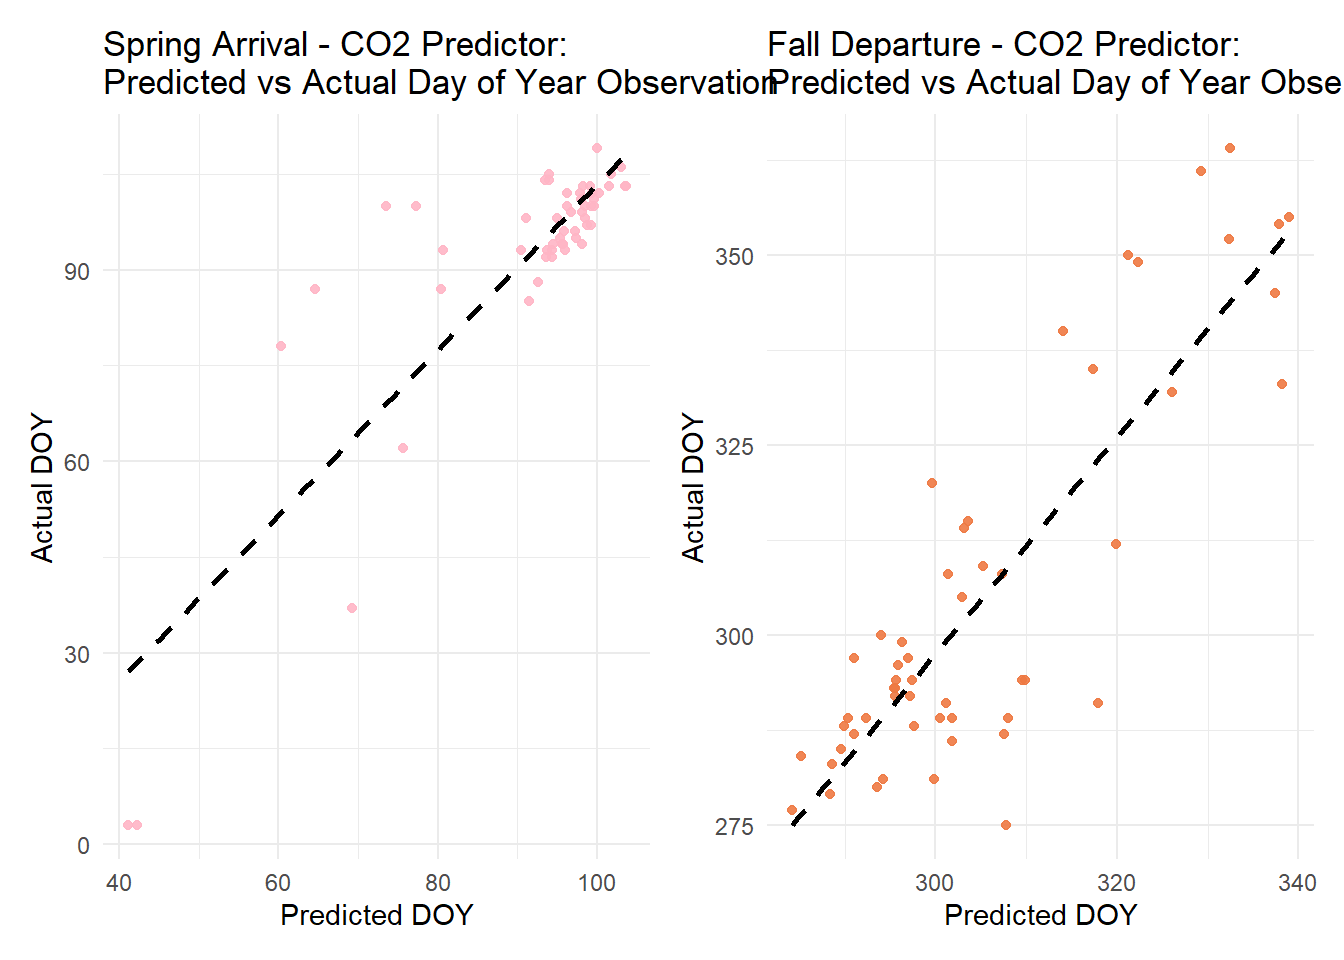

In [ ]:
p3 <- ggplot(CO2_spring_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "pink1") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Spring Arrival - CO2 Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")

p4 <- ggplot(CO2_fall_preds, aes(x = .pred, y = DayOfYear)) +
  geom_point(alpha = 0.9, color = "sienna2") +
  geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Fall Departure - CO2 Predictor:\nPredicted vs Actual Day of Year Observation",
       x = "Predicted DOY", y = "Actual DOY")


p3 + p4

The **random forest model with temperature** as the predictor emerged as the strongest model across both spring arrival and fall departure dates, showing the **lowest RMSE** and **highest R² values**, indicating superior predictive performance and robustness.

### **Spring Arrival Predictions**

The model’s predictions for spring arrival dates showed a **tight clustering along the 1:1 line**, especially near the top-right of the plot. This indicates that as temperatures have risen, **Wood Thrushes are arriving later than expected**. This mismatch in timing may suggest a lag in response to changing environmental cues or a disruption in optimal conditions for early arrival.

The higher accuracy in spring predictions may be because spring arrival is tightly regulated by temperature-dependent cues (such as snow melt, insect emergence, or vegetation growth), making it more sensitive to annual temperature changes.

### **Fall Departure Predictions**

Fall departure predictions demonstrated more **scatter and variability** compared to spring arrival. While the random forest model still performed best, the weaker R² values suggest that **fall migration timing is less directly tied to temperature or CO₂ alone**. The wider spread of points around the 1:1 line, particularly in the lower-left region, implies that **birds are departing earlier than expected** in many cases.

This might indicate that other variables—such as food availability, photoperiod (day length), or precipitation patterns—play a larger role in influencing fall departure behavior.

### **CO₂ vs. Temperature Models**

While temperature-based models consistently outperformed CO₂-based models, the **patterns in both sets of predictions were similar**, suggesting that CO₂ indirectly influences migration phenology through its effect on global temperatures.

Visualizations comparing CO₂ and temperature models showed nearly **parallel trends**, with later spring arrivals and earlier fall departures becoming more common over time—consistent with broader ecological impacts of climate change.

### **Visual Summary**

We generated the following visualizations to illustrate key trends:

-   **Figure 1**: Spring Arrival vs. Annual Temperature

-   **Figure 2**: Fall Departure vs. Annual Temperature

-   **Figure 3**: Spring Arrival vs. Annual CO₂

-   **Figure 4**: Fall Departure vs. Annual CO₂

Each figure includes:

-   A 1:1 reference line for perfect prediction

-   Color scaling by year or observation density (if used)

-   Interpretation notes on clustering trends

These visualizations confirm that the **relationship between climate variables and migration phenology is strong**, particularly for temperature and spring migration events.